# CLN2

In [3]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Define the ODE system
def VDP_CLN2(t, y):
    x1, x2, x3, x4, x5 = y
    dx1 = x2
    dx2 = -x1 + Mu*x2
    dx3 = 2*x4
    dx4 = -x3 + Mu*x4 - Mu*x5
    dx5 = -2 * x4 - 2 * Mu*x5
    return [dx1, dx2, dx3, dx4, dx5]

# Initial conditions
Mu = 1
a = 0.01
b = 0
x0 = [a, b, a**2, a*b, b**2]

# Time span
ts, te = 0, 7
t_eval = np.linspace(ts, te, 100)

# Parameters

# Solve the system
sol_CLN2 = solve_ivp(VDP_CLN2, [ts, te], x0, t_eval=t_eval)

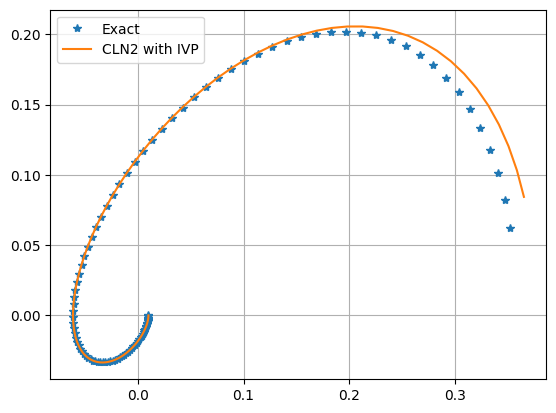

In [4]:
## PLOTTING
plt.plot(sol_exact.y[0], sol_exact.y[1], '*', label='Exact')
plt.plot(sol_CLN2.y[0], sol_CLN2.y[1], label='CLN2 with IVP')

plt.legend()
plt.grid()
plt.savefig("VDPN2-Phase.png")
plt.show()

# QN2

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from qade.bases import basis
from qade.equations import equation, ising, loss, solve
from qade.functions import function
from scipy.optimize import minimize

__all__ = ["basis", "equation", "ising", "loss", "solve", "function"]

import math
from scipy.special import sindg
from scipy.integrate import solve_ivp

# Parameters for the equations
Mu = 1
Tscale = 7
k1 = 1.24 - 0.004 - 0.2

# Sample points
t = np.linspace(0, 1, 100) 

# Functions to solve for
x1, x2, x3, x4, x5 = function(n_in=1, n_out=5)

# Define the equations:
eq1 = equation((x1[1] - (x2[0])*Tscale)/k1, t)
eq2 = equation((x2[1] - (-x1[0] + Mu*x2[0])*Tscale)/k1, t)
eq3 = equation((x3[1] - (2*x4[0])*Tscale)/k1, t)
eq4 = equation((x4[1] - (-x3[0] + Mu*x4[0] + x5[0])*Tscale)/k1, t)
eq5 = equation((x5[1] - (-2*x4[0] + 2*Mu*x5[0]*t)*Tscale)/k1, t)

# Initial conditions:
k2 = 2
ic1 = equation((x1[0] - 0.01)*k2, t[0])
ic2 = equation((x2[0] - 0)*k2, t[0])
ic3 = equation((x3[0] - 0.0001)*k2, t[0])
ic4 = equation((x4[0] - 0)*k2, t[0])
ic5 = equation((x5[0] - 0)*k2, t[0])

# Define Chebyshev basis
chebyshev_basis = basis("chebyshev", size_per_dim=10)

# Solve the system of equations with more reads and classical post-processing
sol_QN2 = solve([eq1, eq2, eq3, eq4, eq5, ic1, ic2, ic3, ic4, ic5], 
                    chebyshev_basis,
                    scales=1, 
                    num_reads=400,  # Increased number of reads
                    n_epochs=50, 
                    n_spins=3, 
                    classical_minimizer=minimize)  # Enable classical post-processing

# Print results
print(f"loss = {sol_QN2.loss}, weights = {np.around(sol_QN2.weights, 2)}")

epoch = 0, loss = 2250.519922238147
epoch = 1, loss = 1662.3274989585927
epoch = 2, loss = 2039.8402590464989
epoch = 3, loss = 1947.1699948342725
epoch = 4, loss = 1654.866684440691
epoch = 5, loss = 1923.6956571811713
epoch = 6, loss = 1554.3332918349906
epoch = 7, loss = 1042.0784469735333
epoch = 8, loss = 1638.8266736322664
epoch = 9, loss = 1601.4915022845278
epoch = 10, loss = 1667.3613854299224
epoch = 11, loss = 1734.2953845136262
epoch = 12, loss = 2027.2909122747408
epoch = 13, loss = 1278.8549689828542
epoch = 14, loss = 1850.8858058677781
epoch = 15, loss = 1717.9923119108587
epoch = 16, loss = 2539.9706538000587
epoch = 17, loss = 2918.926273702793
epoch = 18, loss = 1874.940540932397
epoch = 19, loss = 2446.322852284774
epoch = 20, loss = 2047.5442373096969
epoch = 21, loss = 1268.9129423075276
epoch = 22, loss = 798.5590472128104
epoch = 23, loss = 1079.4630223858715
epoch = 24, loss = 1581.7038016449526
epoch = 25, loss = 1838.0775328969949
epoch = 26, loss = 843.55733

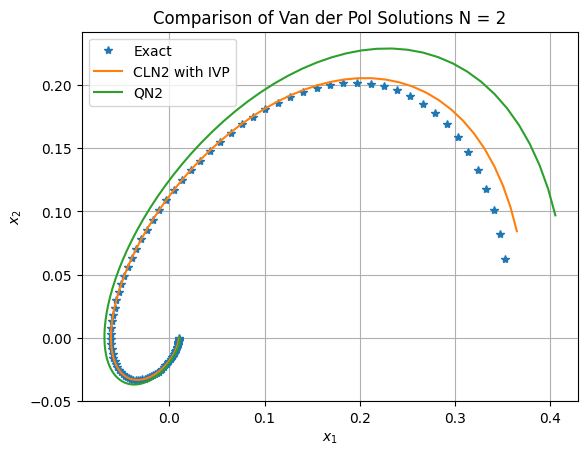

In [6]:
# Plotting the results
plt.plot(sol_exact.y[0], sol_exact.y[1], '*', label='Exact')
plt.plot(sol_CLN2.y[0], sol_CLN2.y[1], label='CLN2 with IVP')
plt.plot(sol_QN2(t)[:, 0], sol_QN2(t)[:, 1], label='QN2')
plt.grid(True)
plt.legend()
plt.title("Comparison of Van der Pol Solutions N = 2")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.savefig("VDPN2-Phase.png") 
plt.show()

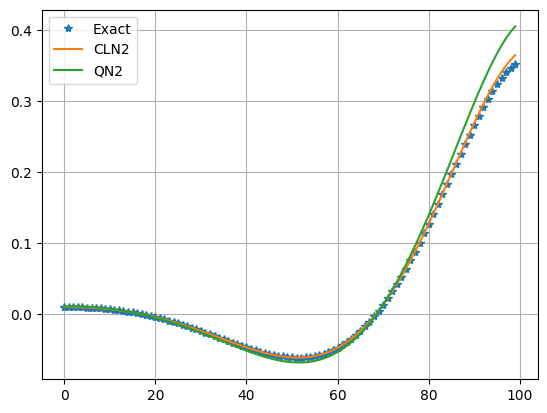

In [7]:
plt.plot(sol_exact.y[0], '*', label='Exact')
plt.plot(sol_CLN2.y[0], label='CLN2')
plt.plot(sol_QN2(t)[:, 0], label='QN2')
plt.grid(True)
plt.legend()
plt.show()
# plt.savefig("VDP_x1.png") 

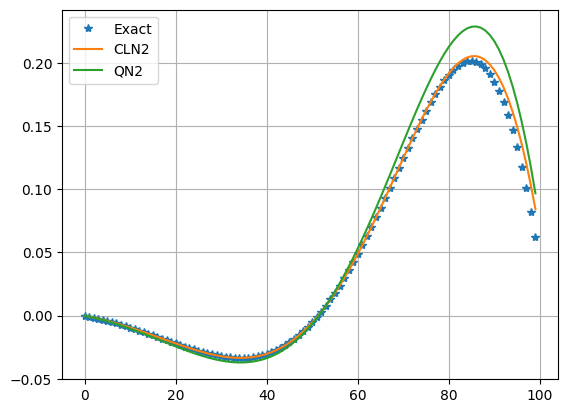

In [8]:
plt.plot(sol_exact.y[1], '*', label='Exact')
plt.plot(sol_CLN2.y[1], label='CLN2')
plt.plot(sol_QN2(t)[:, 1], label='QN2')
plt.grid(True)
plt.legend()
plt.show()
# plt.savefig("VDP_x2.png") 

In [9]:
column1 = sol_QN2(t)[:, 0]
column2 = sol_QN2(t)[:, 1]

import csv
file_path = 'VDP_N2.csv'

# Writing to CSV
with open(file_path, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['x1', 'x2'])  # Write header
    writer.writerows(zip(column1, column2))

# CLN3

In [3]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Define the ODE system
def VDP_CLN3(t, y):
    x1, x2, x3, x4, x5, x6, x7, x8, x9 = y
    dx1 = x2
    dx2 = -x1 + Mu*x2 - Mu*x7
    dx3 = 2*x4
    dx4 = -x3 + Mu*x4 + x5
    dx5 = -2*x4 - 2*Mu*x5
    dx6 = 3*x7
    dx7 = -x6 + Mu*x7 + 2*x8
    dx8 = -2*x7 + 2*Mu*x8 + x9
    dx9 = -3*x8 + 3*Mu*x9
    
    return [dx1, dx2, dx3, dx4, dx5, dx6, dx7, dx8, dx9]

# Initial conditions
Mu = 1
a = 0.01
b = 0
x0 = [a, b, a**2, a*b, b**2, a**3, (a**2)*b, a*(b**2), b**3]

# Time span
ts, te = 0, 7
t_eval = np.linspace(ts, te, 100)

# Parameters

# Solve the system
sol_CLN3 = solve_ivp(VDP_CLN3, [ts, te], x0, t_eval=t_eval)

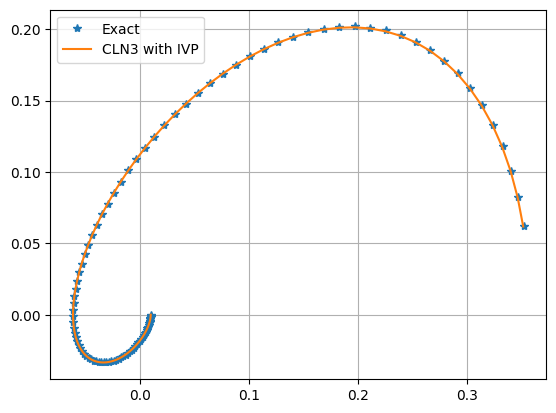

In [4]:
## PLOTTING
plt.plot(sol_exact.y[0], sol_exact.y[1], '*', label='Exact')
plt.plot(sol_CLN3.y[0], sol_CLN3.y[1], label='CLN3 with IVP')

# plt.xlim([-2, 4])
# plt.ylim([-0.2, 0.4])
plt.legend()
plt.grid()
# plt.savefig("VDPN3-Phase.png")
plt.show()

# QN3

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from qade.bases import basis
from qade.equations import equation, ising, loss, solve
from qade.functions import function
from scipy.optimize import minimize

# Sample points
t = np.linspace(0, 1, 100)

# Parameters for the equations
Mu = 1
Tscale = 7
k1 = 18 - 0.1
k1a= 16

# Functions to solve for
x1, x2, x3, x4, x5, x6, x7, x8, x9 = function(n_in=1, n_out=9)
# Define the equations:
eq1 = equation((x1[1] - (x2[0])*Tscale)/k1a, t)
eq2 = equation((x2[1] - (-x1[0] + Mu*x2[0] - Mu*x7[0])*Tscale)/k1a, t)
eq3 = equation((x3[1] - (2*x4[0])*Tscale)/k1, t)
eq4 = equation((x4[1] - (-x3[0] + Mu*x4[0] + x5[0])*Tscale)/k1, t)
eq5 = equation((x5[1] - (-2*x4[0] - 2*Mu*x5[0])*Tscale)/k1, t)
eq6 = equation((x6[1] - (3*x7[0])*Tscale)/k1, t)
eq7 = equation((x7[1] - (-x6[0] + Mu*x7[0] + 2*x8[0])*Tscale)/k1, t)
eq8 = equation((x8[1] - (-2*x7[0] + 2*Mu*x8[0] + x9[0])*Tscale)/k1, t)
eq9 = equation((x9[1] - (-3*x8[0] + 3*Mu*x9[0])*Tscale)/k1, t)

# Define initial conditions:
k2 = 4
k2a= 8

a = 0.01
b = 0
ic1 = equation((x1[0] - a)*k2a, 0)
ic2 = equation((x2[0] - b)*k2a, 0)
ic3 = equation((x3[0] - a**2)*k2, 0)
ic4 = equation((x4[0] - a*b)*k2, 0)
ic5 = equation((x5[0] - b**2)*k2, 0)
ic6 = equation((x6[0] - a**3)*k2, 0)
ic7 = equation((x7[0] - (a**2)*b)*k2, 0)
ic8 = equation((x8[0] - a*(b**2))*k2, 0)
ic9 = equation((x9[0] - b**3)*k2, 0)

# Define Chebyshev basis
chebyshev_basis = basis("chebyshev", size_per_dim=14)

# Solve the system of equations with more reads and classical post-processing
sol_QN3 = solve([eq1, eq2, eq3, eq4, eq5, eq6, eq7, eq8, eq9, 
                 ic1, ic2, ic3, ic4, ic5, ic6, ic7, ic8, ic9], 
                 chebyshev_basis,
                 scales=1, 
                 num_reads=400,  # Increased number of reads
                 n_epochs=50, 
                 n_spins=3, 
                 classical_minimizer=minimize)  # Enable classical post-processing

# Print results
print(f"loss = {sol_QN3.loss}, weights = {np.around(sol_QN3.weights, 2)}")

epoch = 0, loss = 837.3915205264198
epoch = 1, loss = 421.3137119874881
epoch = 2, loss = 253.28372403865052
epoch = 3, loss = 525.4181248746343
epoch = 4, loss = 254.20079687930544
epoch = 5, loss = 874.6281231817461
epoch = 6, loss = 657.8935680070119
epoch = 7, loss = 525.1623330104518
epoch = 8, loss = 869.0045923043152
epoch = 9, loss = 253.7779806692656
epoch = 10, loss = 658.4276246306833
epoch = 11, loss = 254.37536431953052
epoch = 12, loss = 253.88032937206626
epoch = 13, loss = 597.0885844682172
epoch = 14, loss = 494.0666220567887
epoch = 15, loss = 257.09389304029486
epoch = 16, loss = 660.7769240251296
epoch = 17, loss = 251.79668868191723
epoch = 18, loss = 656.7088740223094
epoch = 19, loss = 1460.9794011389035
epoch = 20, loss = 840.8356619644202
epoch = 21, loss = 253.61231223935155
epoch = 22, loss = 595.5110331425119
epoch = 23, loss = 420.2252827995088
epoch = 24, loss = 841.8335391152968
epoch = 25, loss = 253.73552143043412
epoch = 26, loss = 495.23541732244144
e

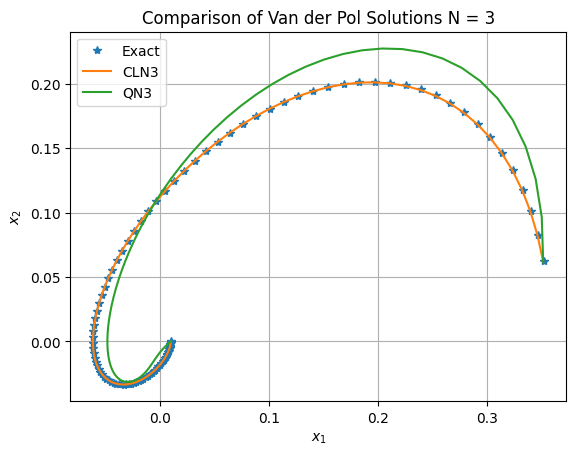

In [6]:
# Plotting the results
plt.plot(sol_exact.y[0], sol_exact.y[1], '*', label='Exact')
plt.plot(sol_CLN3.y[0], sol_CLN3.y[1], label='CLN3')
plt.plot(sol_QN3(t)[:, 0], sol_QN3(t)[:, 1], label='QN3')
plt.grid(True)
plt.legend()
plt.title("Comparison of Van der Pol Solutions N = 3")
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.savefig("VDPN3-Phase.png")
plt.show()

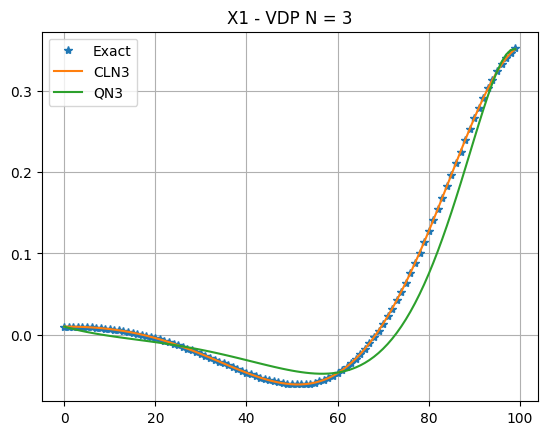

In [7]:
# Plotting the results
plt.plot(sol_exact.y[0], '*', label='Exact')
plt.plot(sol_CLN3.y[0], label='CLN3')
plt.plot(sol_QN3(t)[:, 0], label='QN3')
plt.grid(True)
plt.legend()
plt.title("X1 - VDP N = 3")
plt.savefig("VDPN3-x1.png")
plt.show()

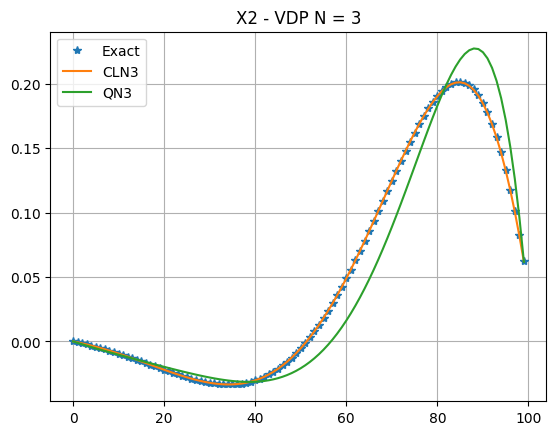

In [8]:
# Plotting the results
plt.plot(sol_exact.y[1], '*', label='Exact')
plt.plot(sol_CLN3.y[1], label='CLN3')
plt.plot(sol_QN3(t)[:, 1], label='QN3')
plt.grid(True)
plt.legend()
plt.title("X2 - VDP N = 3")
plt.savefig("VDPN3-x2.png")
plt.show()

In [9]:
col1_QN3 = sol_QN3(t)[:, 0]
col2_QN3 = sol_QN3(t)[:, 1]

import csv
file_path = 'VDP_N3.csv'

# Writing to CSV
with open(file_path, 'w', newline='') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(['x1', 'x2'])  # Write header
    writer.writerows(zip(col1_QN3, col2_QN3))

***